In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   
2     261251  Item Name: Bear Creek Hearty Soup Bowl, Creamy...   
3      55858  Item Name: Judee’s Blue Cheese Powder 11.25 oz...   
4     292686  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...   

                                          image_link  price  
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89  
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12  
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   1.97  
3  https://m.media-amazon.com/images/I/41mu0HAToD...  30.34  
4  https://m.media-amazon.com/images/I/41sA037+Qv...  66.49  
           sample_id         price
count   75000.000000  75000.000000
mean   149841.917707     23.647654
std     86585.346513     33.376932
min         0.000000      0.130000
25%     73845.750000      6.795000
50%    150129.0

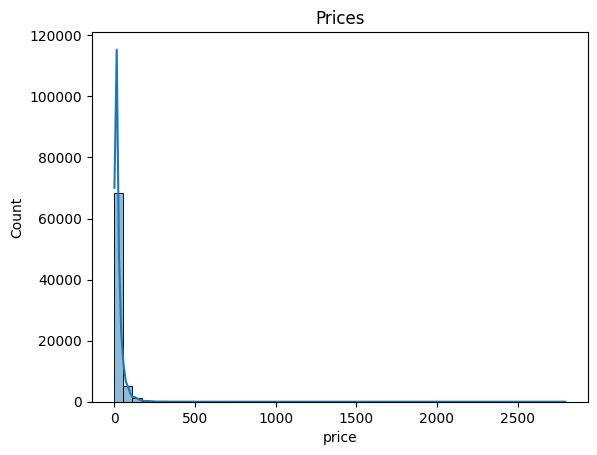

In [2]:
train_df = pd.read_csv(r'dataset/train.csv')
print(train_df.head())
print(train_df.describe())
sns.histplot(train_df['price'], bins=50, kde=True)
plt.title('Prices')
plt.show()

           sample_id         price     log_price
count   75000.000000  75000.000000  75000.000000
mean   149841.917707     23.647654      2.739217
std     86585.346513     33.376932      0.942032
min         0.000000      0.130000      0.122218
25%     73845.750000      6.795000      2.053483
50%    150129.000000     14.000000      2.708050
75%    225040.250000     28.625000      3.388619
max    299438.000000   2796.000000      7.936303


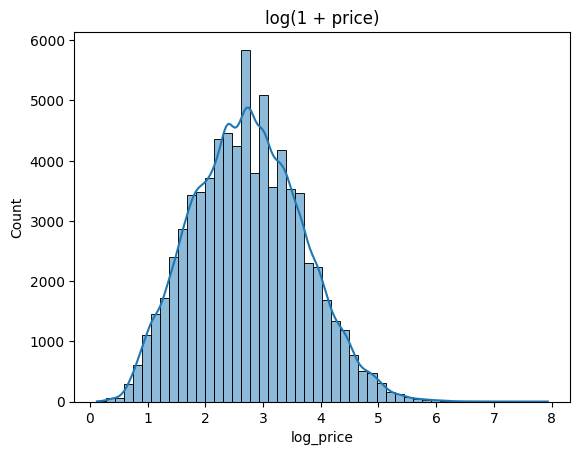

In [3]:
train_df['log_price'] = np.log1p(train_df['price'])
print(train_df.describe())
sns.histplot(train_df['log_price'], bins=50, kde=True)
plt.title('log(1 + price)')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X = train_df['catalog_content']
y = train_df['log_price']

X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.75, test_size=0.25, random_state=42, shuffle=True)

print(f'{X_train.head()}\n{X_val.head()}')
print(f'{X_train.shape}\n{X_val.shape}')

1762     Item Name: Royal Brown Basmati Rice - Authenti...
16752    Item Name: Loma Linda® Veja-Links® (15 oz.) - ...
1888     Item Name: Bits N Things Gold Medal Baking Mix...
15537    Item Name: Sello Rojo, Espresso Brick, 10 oz, ...
20060    Item Name: Great River Organic Milling Organic...
Name: catalog_content, dtype: object
26837    Item Name: Log Cabin Sugar Free Syrup, 24 FL O...
2592     Item Name: Raspberry Ginseng Oolong Tea (50 te...
18359    Item Name: Walden Farms Honey Dijon Dressing -...
73292    Item Name: Vlasic Ovals Hamburger Dill Pickle ...
60127    Item Name: Amoretti Premium Syrup, Grand Orang...
Name: catalog_content, dtype: object
(56250,)
(18750,)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print(f'{X_train_tfidf.shape}\n{X_val_tfidf.shape}')

(56250, 5000)
(18750, 5000)


RMSE : 33.55862672112243	MAE : 13.435931013464076	SMAPE : 58.161%


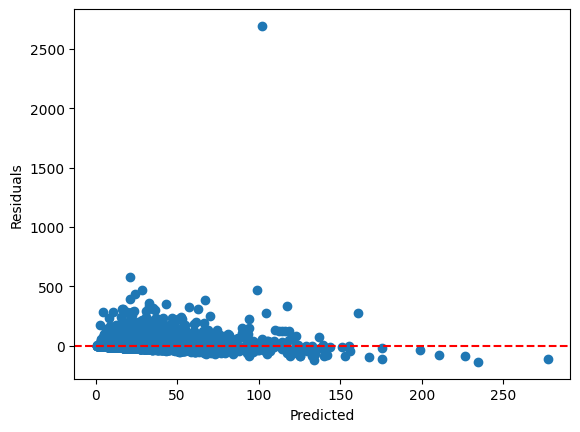

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_tfidf, y_train)

y_pred = ridge_model.predict(X_val_tfidf)

y_pred_price = np.expm1(y_pred)
y_val_price = np.expm1(y_val)

rmse = np.sqrt(mean_squared_error(y_val_price, y_pred_price))
mae = mean_absolute_error(y_val_price, y_pred_price)
smape = np.mean(abs(y_pred_price - y_val_price) / ((abs(y_val_price) + abs(y_pred_price))/2)) * 100

print(f'RMSE : {rmse}\tMAE : {mae}\tSMAPE : {smape:.3f}%')

residual = y_val_price - y_pred_price
plt.scatter(y_pred_price, residual)
plt.axhline(0, color='r', linestyle='--')
plt.ylabel('Residuals')
plt.xlabel('Predicted')
plt.show()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.294519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 496773
[LightGBM] [Info] Number of data points in the train set: 56250, number of used features: 4976
[LightGBM] [Info] Start training from score 2.741782


/home/rishav/code/venv/lib64/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE : 32.3435551047173	MAE : 12.230634957352786	SMAPE : 54.652%


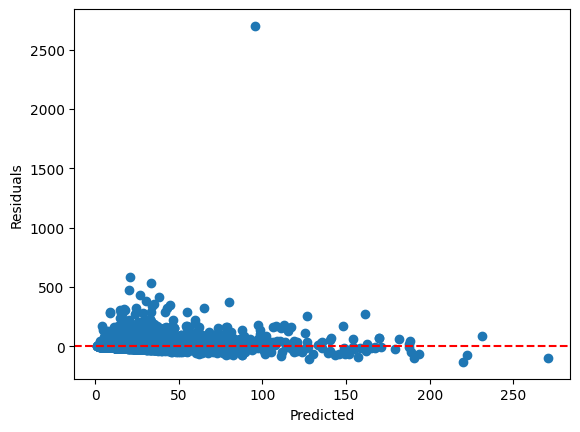

In [7]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31)
lgbm.fit(X_train_tfidf, y_train)

y_pred = lgbm.predict(X_val_tfidf)

y_pred_price = np.expm1(y_pred)
y_val_price = np.expm1(y_val)

rmse = np.sqrt(mean_squared_error(y_val_price, y_pred_price))
mae = mean_absolute_error(y_val_price, y_pred_price)
smape = np.mean(abs(y_pred_price - y_val_price) / ((abs(y_val_price) + abs(y_pred_price))/2)) * 100

print(f'RMSE : {rmse}\tMAE : {mae}\tSMAPE : {smape:.3f}%')

residual = y_val_price - y_pred_price
plt.scatter(y_pred_price, residual)
plt.axhline(0, color='r', linestyle='--')
plt.ylabel('Residuals')
plt.xlabel('Predicted')
plt.show()

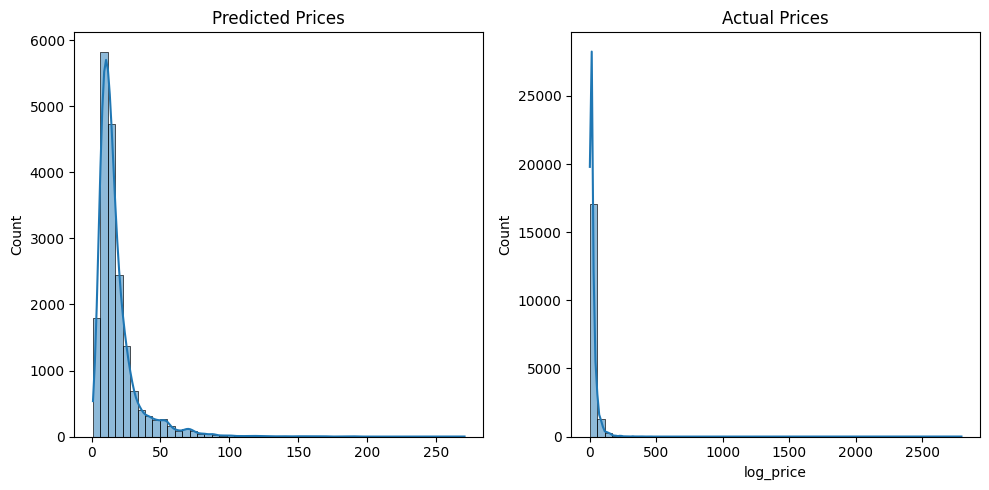

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_pred_price, bins=50, kde=True)
plt.title('Predicted Prices')

plt.subplot(1, 2, 2)
sns.histplot(y_val_price, bins=50, kde=True)
plt.title('Actual Prices')

plt.tight_layout()
plt.show()

In [11]:
analysis_df = pd.DataFrame({'true_price':y_val_price,
                            'predicted_price':y_pred_price,
                            'mae':np.abs(y_val_price - y_pred_price)})
analysis_df['catalog_content'] = train_df.loc[y_val_price.index, 'catalog_content']

worst_predictions = analysis_df.sort_values(by='mae', ascending=False)
worst_predictions.to_csv('worst_predictions.csv', index=False)
print(worst_predictions.head(20))

       true_price  predicted_price          mae  \
58617     2796.00        95.582781  2700.417219   
34167      600.59        20.526766   580.063234   
38896      570.00        33.504661   536.495339   
47257      496.28        19.915436   476.364564   
58071      459.95        26.567299   433.382701   
58979      454.99        37.874219   417.115781   
19753      413.99        30.303450   383.686550   
67900      454.98        79.970695   375.009305   
6213       390.98        35.076985   355.903015   
11567      390.00        44.737727   345.262273   
71686      369.99        34.224142   335.765858   
4859       369.81        43.091598   326.718402   
6691       349.95        24.230565   325.719435   
14004      386.98        64.789031   322.190969   
2218       328.60        17.494872   311.105128   
40050      323.86        14.607926   309.252074   
68215      319.89        17.716247   302.173753   
4735       333.27        41.600823   291.669177   
86         298.00         8.989